Aishi De

Sem 7 , Sec A

Data Science

# PROJECT: **ASPIRE** - Academic Success Prediction through Intelligent Risk Evaluation

End-to-End Analysis, Predictive Modeling, and Evaluation Pipeline

RUNTIME: R

[SUCCESS] Reading dataset from: 'Student_Performance_Factors_Dataset.csv'
Loaded dataset: 6607 rows, 20 columns.

Target column: 'exam_score'
Intervention Score Threshold (<= 25th percentile): 65.00
Class Balance:

High_Risk    Normal 
     2131      4476 

>>> Training Logistic Regression...
>>> Training Random Forest Classifier...
>>> Training Gradient Boosting Machine (GBM)...

          RANDOM FOREST CLASSIFICATION METRICS         
Confusion Matrix and Statistics

           Reference
Prediction  High_Risk Normal
  High_Risk       350     41
  Normal           76    854
                                          
               Accuracy : 0.9114          
                 95% CI : (0.8948, 0.9262)
    No Information Rate : 0.6775          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.7929          
                                          
 Mcnemar's Test P-Value : 0.001671        
                                

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases



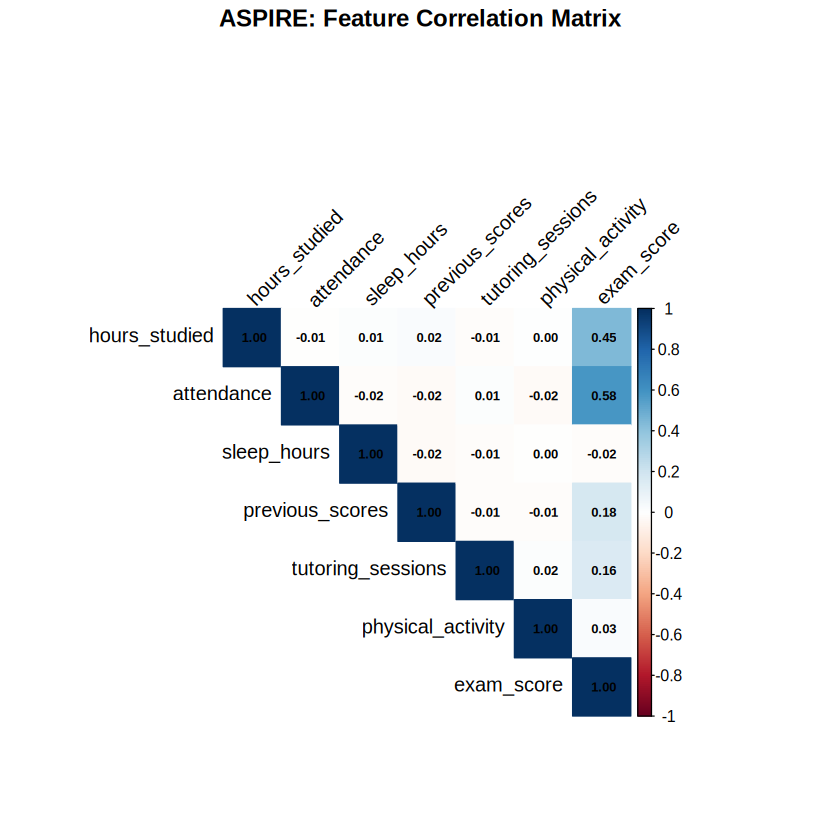

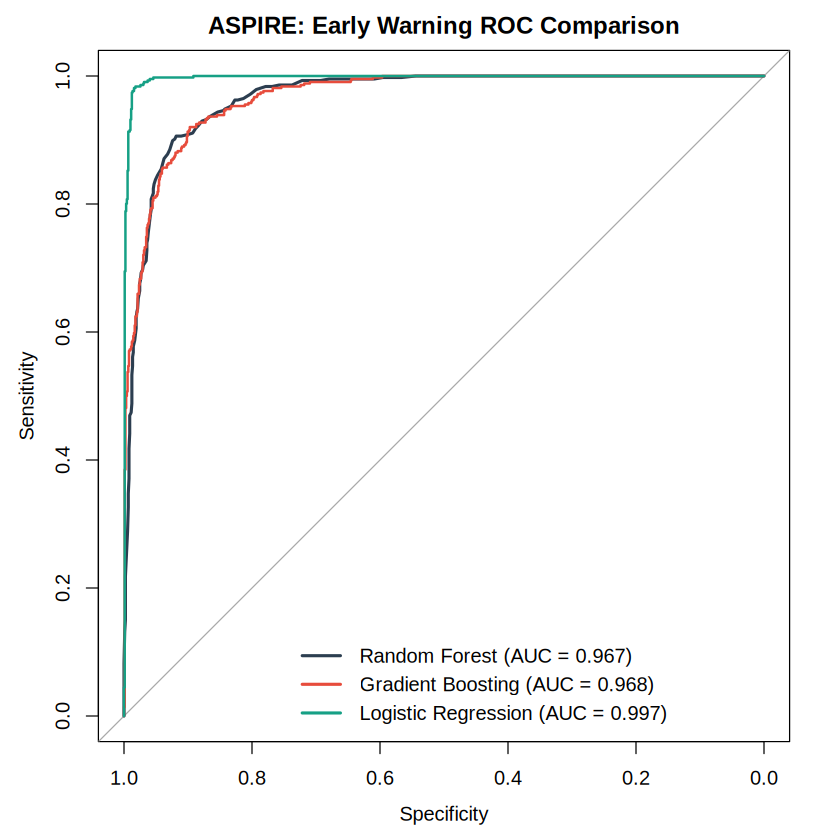

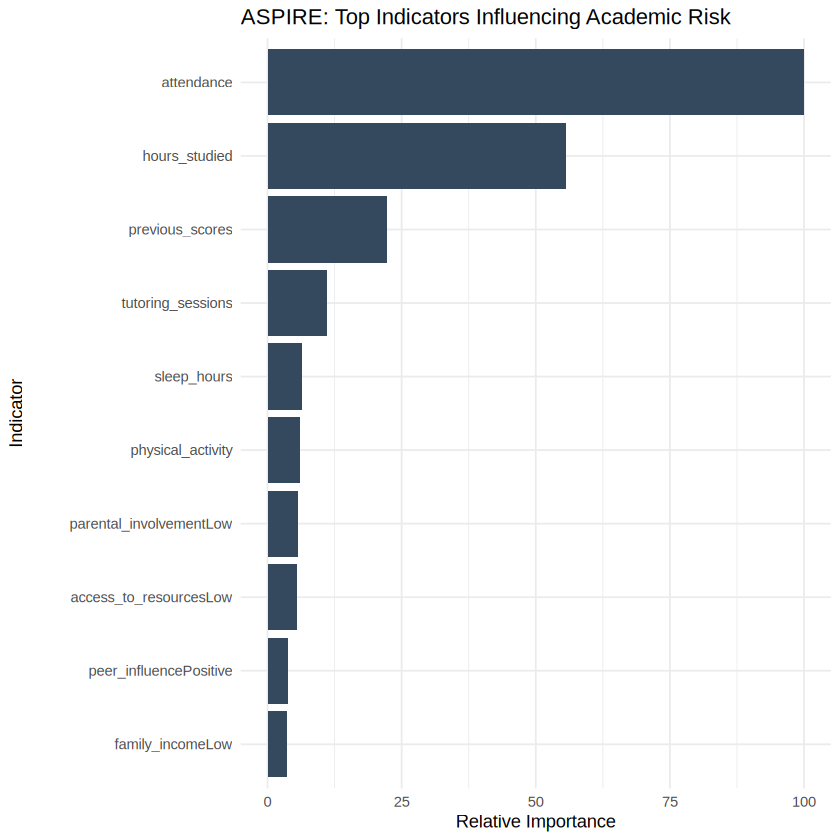


>>> Pipeline execution completed successfully.


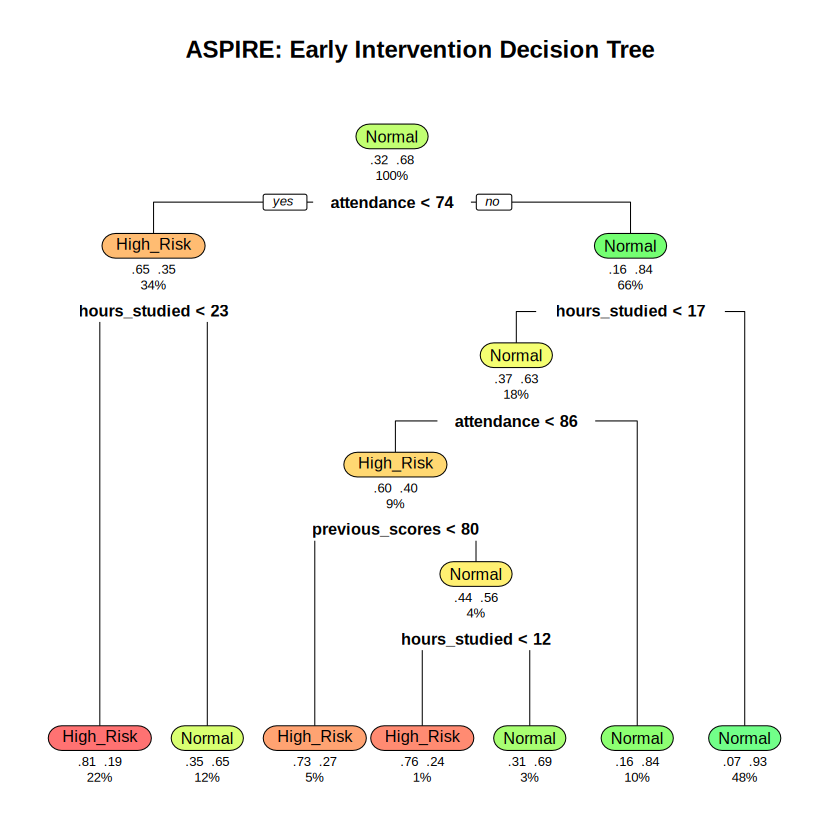

In [17]:
required_packages <- c(
  "tidyverse", "caret", "randomForest", "gbm",
  "pROC", "corrplot", "rpart", "rpart.plot", "e1071"
)

installed <- installed.packages()[, "Package"]
missing_packages <- required_packages[!required_packages %in% installed]

if (length(missing_packages) > 0) {
  cat("Installing required packages...\n")
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}

suppressPackageStartupMessages({
  library(tidyverse)
  library(caret)
  library(randomForest)
  library(gbm)
  library(pROC)
  library(corrplot)
  library(rpart)
  library(rpart.plot)
  library(e1071)
})


file_name <- "Student_Performance_Factors_Dataset.csv"
if (!file.exists(file_name)) {
  stop("Dataset file not found! Verify it is in the Files sidebar.")
}

cat(sprintf("[SUCCESS] Reading dataset from: '%s'\n", file_name))
df_raw <- read.csv(file_name, stringsAsFactors = FALSE)
cat(sprintf("Loaded dataset: %d rows, %d columns.\n\n", nrow(df_raw), ncol(df_raw)))


names(df_raw) <- tolower(gsub("[ .]", "_", names(df_raw)))

target_col <- grep("exam_score", names(df_raw), value = TRUE)
if (length(target_col) == 0) {
  target_col <- names(df_raw)[ncol(df_raw)]
}
cat(sprintf("Target column: '%s'\n", target_col))

df_clean <- df_raw %>%
  mutate(across(where(is.numeric), ~ ifelse(is.na(.), median(., na.rm = TRUE), .))) %>%
  mutate(across(where(is.character), ~ ifelse(is.na(.) | trimws(.) == "", "Unknown", trimws(.)))) %>%
  mutate(across(where(is.character), as.factor))


risk_threshold <- as.numeric(quantile(df_clean[[target_col]], 0.25, na.rm = TRUE))
cat(sprintf("Intervention Score Threshold (<= 25th percentile): %.2f\n", risk_threshold))

df_model <- df_clean %>%
  mutate(
    risk_status = factor(
      ifelse(.data[[target_col]] <= risk_threshold, "High_Risk", "Normal"),
      levels = c("High_Risk", "Normal")
    )
  )

cat("Class Balance:\n")
print(table(df_model$risk_status))


num_cols <- df_model %>% select(where(is.numeric))
if (ncol(num_cols) > 1) {
  cor_mat <- cor(num_cols, use = "complete.obs")
  corrplot(
    cor_mat, method = "color", type = "upper",
    tl.col = "black", tl.srt = 45, addCoef.col = "black",
    number.cex = 0.65, title = "ASPIRE: Feature Correlation Matrix",
    mar = c(0, 0, 1.5, 0)
  )
}

# Train/Test Split (80/20)
set.seed(42)
train_idx <- createDataPartition(df_model$risk_status, p = 0.80, list = FALSE)

features <- df_model %>% select(-all_of(c(target_col, "risk_status")))

train_data <- features[train_idx, ]
train_data$risk_status <- df_model$risk_status[train_idx]

test_data <- features[-train_idx, ]
test_labels <- df_model$risk_status[-train_idx]

# Model Training (5-Fold CV)
cv_control <- trainControl(
  method = "cv", number = 5,
  classProbs = TRUE,
  summaryFunction = twoClassSummary,
  savePredictions = "final"
)

cat("\n>>> Training Logistic Regression...\n")
fit_glm <- suppressWarnings(
  train(risk_status ~ ., data = train_data, method = "glm", family = "binomial", metric = "ROC", trControl = cv_control)
)

cat(">>> Training Random Forest Classifier...\n")
fit_rf <- train(risk_status ~ ., data = train_data, method = "rf", ntree = 100, metric = "ROC", trControl = cv_control)

cat(">>> Training Gradient Boosting Machine (GBM)...\n")
fit_gbm <- train(
  risk_status ~ ., data = train_data, method = "gbm",
  metric = "ROC", trControl = cv_control,
  verbose = FALSE, tuneLength = 2
)

# Model Evaluation & ROC Comparison
pred_rf  <- predict(fit_rf, test_data)
prob_rf  <- predict(fit_rf, test_data, type = "prob")$High_Risk

pred_gbm <- predict(fit_gbm, test_data)
prob_gbm <- predict(fit_gbm, test_data, type = "prob")$High_Risk

pred_glm <- predict(fit_glm, test_data)
prob_glm <- predict(fit_glm, test_data, type = "prob")$High_Risk

cat("\n======================================================\n")
cat("          RANDOM FOREST CLASSIFICATION METRICS         \n")
cat("======================================================\n")
print(confusionMatrix(pred_rf, test_labels, positive = "High_Risk"))

# Generate ROC Curves
roc_rf  <- roc(test_labels, prob_rf, levels = c("Normal", "High_Risk"))
roc_gbm <- roc(test_labels, prob_gbm, levels = c("Normal", "High_Risk"))
roc_glm <- roc(test_labels, prob_glm, levels = c("Normal", "High_Risk"))

plot(roc_rf, col = "#2C3E50", lwd = 2.5, main = "ASPIRE: Early Warning ROC Comparison")
lines(roc_gbm, col = "#E74C3C", lwd = 2)
lines(roc_glm, col = "#16A085", lwd = 2)
legend("bottomright", legend = c(
  sprintf("Random Forest (AUC = %.3f)", auc(roc_rf)),
  sprintf("Gradient Boosting (AUC = %.3f)", auc(roc_gbm)),
  sprintf("Logistic Regression (AUC = %.3f)", auc(roc_glm))
), col = c("#2C3E50", "#E74C3C", "#16A085"), lwd = 2.5, bty = "n")

# Variable Importance Plot
rf_imp <- varImp(fit_rf)$importance
rf_imp$Feature <- rownames(rf_imp)

p_imp <- ggplot(head(rf_imp %>% arrange(desc(Overall)), 10), aes(x = reorder(Feature, Overall), y = Overall)) +
  geom_bar(stat = "identity", fill = "#34495E") +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "ASPIRE: Top Indicators Influencing Academic Risk",
    x = "Indicator", y = "Relative Importance"
  )
print(p_imp)

# Decision Tree for Classroom Intervention Rules
tree_fit <- rpart(risk_status ~ ., data = train_data, method = "class", control = rpart.control(cp = 0.015))
rpart.plot(
  tree_fit, type = 2, extra = 104, under = TRUE,
  box.palette = "RdYlGn",
  main = "ASPIRE: Early Intervention Decision Tree"
)

cat("\n>>> Pipeline execution completed successfully.\n")

>>> [1/3] Generating Educator Early Intervention Triage Roster...
Identified 391 students flagged for intervention in the validation cohort.

Top 5 Highest-Risk Students Identified by ASPIRE:
  risk_probability       intervention_priority hours_studied attendance
1                1 Critical (Immediate Action)            15         70
2                1 Critical (Immediate Action)            14         65
3                1 Critical (Immediate Action)            17         61
4                1 Critical (Immediate Action)            15         65
5                1 Critical (Immediate Action)            11         63
  tutoring_sessions actual_status
1                 1     High_Risk
2                 1     High_Risk
3                 1     High_Risk
4                 1     High_Risk
5                 0     High_Risk

[SAVED] Intervention roster exported to 'aspire_intervention_roster.csv'.

>>> [2/3] Training Continuous Score Predictor (Random Forest Regressor)...

          ASPIRE EXA

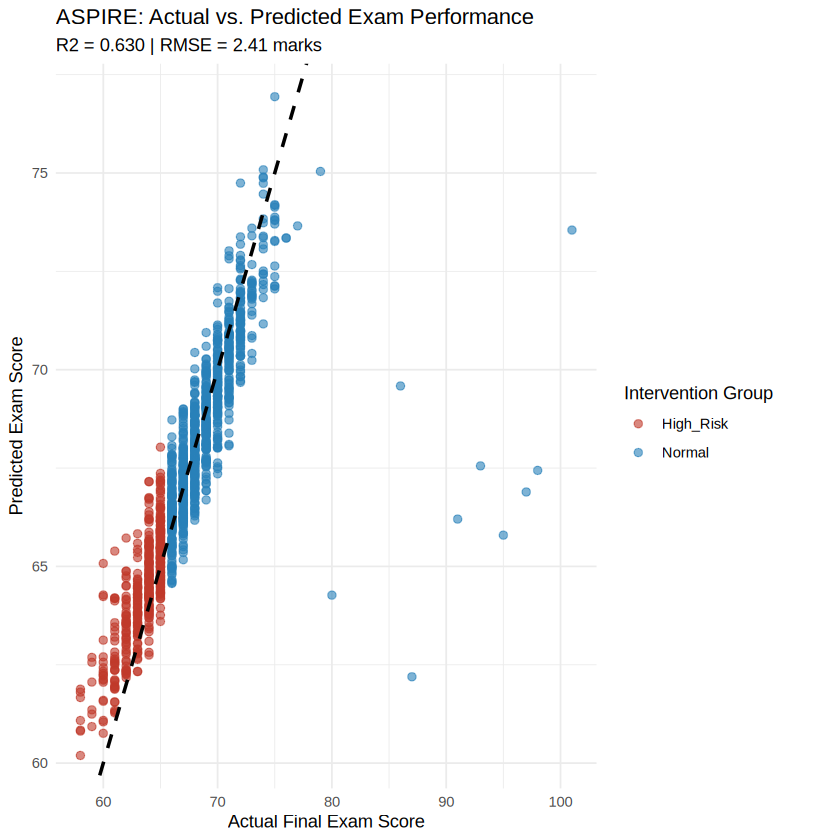

In [18]:
# EARLY INTERVENTION TRIAGE & SCORE REGRESSION MODELING

# 1. ACTIONABLE INTERVENTION TRIAGE ROSTER (FOR EDUCATORS)
cat(">>> [1/3] Generating Educator Early Intervention Triage Roster...\n")

# Combine test data features with predicted risk probabilities
triage_df <- test_data %>%
  mutate(
    actual_status = test_labels,
    predicted_status = pred_rf,
    risk_probability = round(prob_rf, 4),
    intervention_priority = case_when(
      risk_probability >= 0.75 ~ "Critical (Immediate Action)",
      risk_probability >= 0.50 ~ "High Priority",
      risk_probability >= 0.25 ~ "Moderate Watchlist",
      TRUE ~ "Low / On-Track"
    )
  )

# Extract top high-risk candidates needing intervention
action_roster <- triage_df %>%
  filter(predicted_status == "High_Risk") %>%
  arrange(desc(risk_probability))

cat(sprintf("Identified %d students flagged for intervention in the validation cohort.\n", nrow(action_roster)))
cat("\nTop 5 Highest-Risk Students Identified by ASPIRE:\n")
print(head(action_roster %>% select(risk_probability, intervention_priority, hours_studied, attendance, tutoring_sessions, actual_status), 5))

# Export clean intervention CSV for school counselors/teachers
write.csv(action_roster, "aspire_intervention_roster.csv", row.names = FALSE)
cat("\n[SAVED] Intervention roster exported to 'aspire_intervention_roster.csv'.\n\n")


# 2. CONTINUOUS EXAM SCORE REGRESSION (PREDICTING EXACT MARKS)

cat(">>> [2/3] Training Continuous Score Predictor (Random Forest Regressor)...\n")

y_train_score <- df_clean[[target_col]][train_idx]
y_test_score  <- df_clean[[target_col]][-train_idx]

reg_train_data <- features[train_idx, ]
reg_train_data$exam_score <- y_train_score

# Fit Random Forest Regressor
fit_reg_rf <- randomForest(
  exam_score ~ .,
  data = reg_train_data,
  ntree = 120,
  importance = TRUE
)

# Predict continuous exam scores on unseen test data
score_preds <- predict(fit_reg_rf, test_data)

# Compute Regression Metrics
reg_rmse <- Metrics::rmse(y_test_score, score_preds)
reg_mae  <- Metrics::mae(y_test_score, score_preds)
reg_r2   <- 1 - (sum((y_test_score - score_preds)^2) / sum((y_test_score - mean(y_test_score))^2))

cat("\n======================================================\n")
cat("          ASPIRE EXAM SCORE FORECASTING METRICS       \n")
cat("======================================================\n")
cat(sprintf("R-squared (R2)                 : %.4f (%.1f%% variance explained)\n", reg_r2, reg_r2 * 100))
cat(sprintf("Root Mean Squared Error (RMSE) : %.2f marks\n", reg_rmse))
cat(sprintf("Mean Absolute Error (MAE)      : %.2f marks\n", reg_mae))
cat("======================================================\n\n")


# 3. ACTUAL VS. PREDICTED SCORE VISUALIZATION

cat(">>> [3/3] Plotting Actual vs. Predicted Performance Curve...\n")

plot_df <- data.frame(
  Actual = y_test_score,
  Predicted = score_preds,
  Risk = test_labels
)

p_reg <- ggplot(plot_df, aes(x = Actual, y = Predicted, color = Risk)) +
  geom_point(alpha = 0.6, size = 2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "black", linewidth = 1) +
  scale_color_manual(values = c("High_Risk" = "#C0392B", "Normal" = "#2980B9")) +
  theme_minimal() +
  labs(
    title = "ASPIRE: Actual vs. Predicted Exam Performance",
    subtitle = sprintf("R2 = %.3f | RMSE = %.2f marks", reg_r2, reg_rmse),
    x = "Actual Final Exam Score",
    y = "Predicted Exam Score",
    color = "Intervention Group"
  )

print(p_reg)

cat("\n>>> Part 2 complete! You can download 'aspire_intervention_roster.csv' from the left file pane.\n")

>>> [1/2] Computing standardized evaluation metrics on test partition...
>>> [2/2] Generating IEEE Format Benchmark Table...

TABLE I
PERFORMANCE METRICS EVALUATION FOR EARLY ACADEMIC INTERVENTION PREDICTION (TEST PARTITION N = 1321)
Algorithm                  | Accuracy   | Sensitivity | Specificity | Precision  | F1-Score   | AUC-ROC 
---------------------------------------------------------------------------------------------------
Random Forest              | 0.9114     | 0.8216      | 0.9542      | 0.8951     | 0.8568     | 0.9673  
Gradient Boosting (GBM)    | 0.9031     | 0.7864      | 0.9587      | 0.9005     | 0.8396     | 0.9675  
Logistic Regression        | 0.9765     | 0.9531      | 0.9877      | 0.9736     | 0.9632     | 0.9968  
Note: Positive Class = 'High_Risk'. Sensitivity denotes Recall for proactive identification.

[SAVED] IEEE formatted summary table exported to 'ASPIRE_IEEE_Benchmark_Table.txt'.


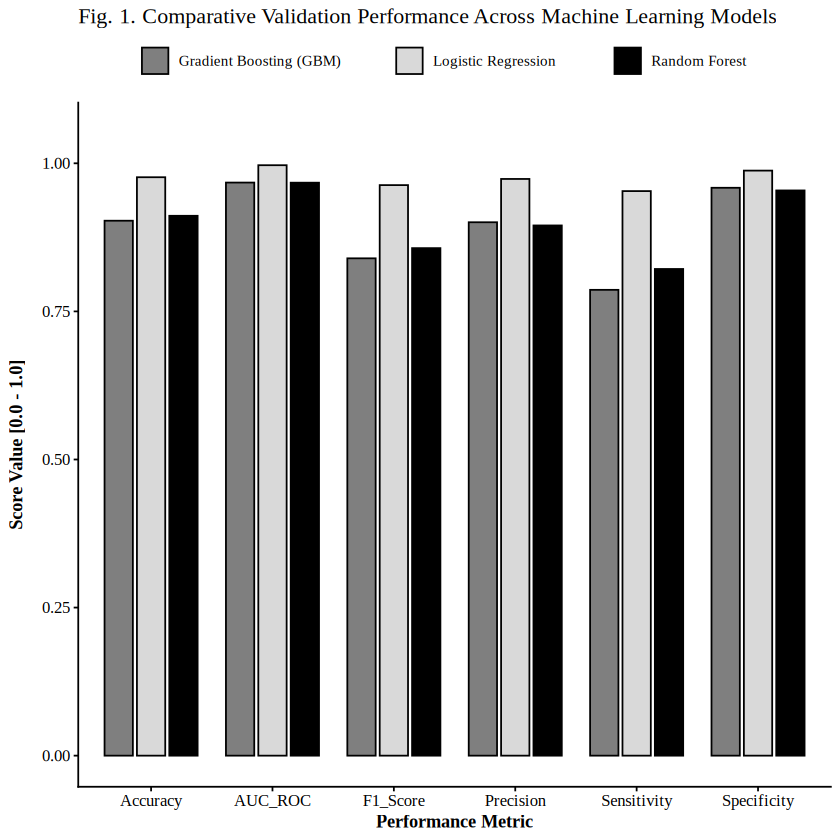

In [19]:
# ASPIRE PART 4: EXECUTIVE MODEL BENCHMARKING & IEEE-STYLE REPORTING


# 1. COMPUTE PERFORMANCE METRICS ACROSS ALL THREE MODELS

cat(">>> [1/2] Computing standardized evaluation metrics on test partition...\n")

calc_metrics <- function(pred_class, pred_prob, true_class, model_name) {
  cm <- confusionMatrix(pred_class, true_class, positive = "High_Risk")
  roc_obj <- roc(true_class, pred_prob, levels = c("Normal", "High_Risk"), quiet = TRUE)

  acc   <- cm$overall["Accuracy"]
  sens  <- cm$byClass["Sensitivity"]   # Recall (Catching at-risk students)
  spec  <- cm$byClass["Specificity"]
  prec  <- cm$byClass["Precision"]     # Positive Predictive Value
  f1    <- cm$byClass["F1"]
  auc_v <- as.numeric(auc(roc_obj))

  data.frame(
    Model       = model_name,
    Accuracy    = sprintf("%.4f", acc),
    Sensitivity = sprintf("%.4f", sens),
    Specificity = sprintf("%.4f", spec),
    Precision   = sprintf("%.4f", prec),
    F1_Score    = sprintf("%.4f", f1),
    AUC_ROC     = sprintf("%.4f", auc_v),
    stringsAsFactors = FALSE
  )
}

benchmark_rf  <- calc_metrics(pred_rf, prob_rf, test_labels, "Random Forest")
benchmark_gbm <- calc_metrics(pred_gbm, prob_gbm, test_labels, "Gradient Boosting (GBM)")
benchmark_glm <- calc_metrics(pred_glm, prob_glm, test_labels, "Logistic Regression")

benchmark_summary <- bind_rows(benchmark_rf, benchmark_gbm, benchmark_glm)


# 2. IEEE-COMPLIANT BLACK-AND-WHITE BENCHMARK TABLE

cat(">>> [2/2] Generating IEEE Format Benchmark Table...\n\n")

# Display textual IEEE Table
ieee_banner <- paste0(
  "TABLE I\n",
  "PERFORMANCE METRICS EVALUATION FOR EARLY ACADEMIC INTERVENTION PREDICTION (TEST PARTITION N = ", length(test_labels), ")\n",
  "===================================================================================================\n",
  sprintf("%-26s | %-10s | %-11s | %-11s | %-10s | %-10s | %-8s\n",
          "Algorithm", "Accuracy", "Sensitivity", "Specificity", "Precision", "F1-Score", "AUC-ROC"),
  "---------------------------------------------------------------------------------------------------\n"
)

cat(ieee_banner)
for (i in 1:nrow(benchmark_summary)) {
  row <- benchmark_summary[i, ]
  cat(sprintf("%-26s | %-10s | %-11s | %-11s | %-10s | %-10s | %-8s\n",
              row$Model, row$Accuracy, row$Sensitivity, row$Specificity, row$Precision, row$F1_Score, row$AUC_ROC))
}
cat("===================================================================================================\n")
cat("Note: Positive Class = 'High_Risk'. Sensitivity denotes Recall for proactive identification.\n\n")

# Save table to a file for direct use in paper/report
sink("ASPIRE_IEEE_Benchmark_Table.txt")
cat(ieee_banner)
for (i in 1:nrow(benchmark_summary)) {
  row <- benchmark_summary[i, ]
  cat(sprintf("%-26s | %-10s | %-11s | %-11s | %-10s | %-10s | %-8s\n",
              row$Model, row$Accuracy, row$Sensitivity, row$Specificity, row$Precision, row$F1_Score, row$AUC_ROC))
}
cat("===================================================================================================\n")
sink()


# 3. IEEE-STYLE BLACK-AND-WHITE VISUAL PLOT (TIMES NEW ROMAN / MONOCHROME)

metrics_long <- benchmark_summary %>%
  pivot_longer(cols = -Model, names_to = "Metric", values_to = "Value") %>%
  mutate(Value = as.numeric(Value))

p_ieee <- ggplot(metrics_long, aes(x = Metric, y = Value, fill = Model)) +
  geom_bar(stat = "identity", position = position_dodge(0.8), width = 0.7, color = "black") +
  scale_fill_manual(values = c("Random Forest" = "black",
                               "Gradient Boosting (GBM)" = "grey50",
                               "Logistic Regression" = "grey85")) +
  theme_classic(base_family = "serif") +  # serif = Times New Roman rendering
  theme(
    text = element_text(color = "black"),
    axis.title = element_text(face = "bold", size = 11),
    axis.text = element_text(color = "black", size = 10),
    legend.position = "top",
    legend.title = element_blank(),
    legend.text = element_text(size = 9)
  ) +
  labs(
    title = "Fig. 1. Comparative Validation Performance Across Machine Learning Models",
    x = "Performance Metric",
    y = "Score Value [0.0 - 1.0]"
  ) +
  ylim(0, 1.05)

print(p_ieee)

cat("[SAVED] IEEE formatted summary table exported to 'ASPIRE_IEEE_Benchmark_Table.txt'.\n")

In [21]:

# ASPIRE PART 5: MODEL ARTIFACT SERIALIZATION & BATCH INFERENCE PIPELINE


# 1. SAVE PRODUCTION ARTIFACTS

cat(">>> [1/3] Serializing production models and deployment metadata...\n")

if (!dir.exists("models")) {
  dir.create("models")
}

# Ensure cohort_summary exists (recalculate if Part 3 was skipped or cleared)
if (!exists("cohort_summary")) {
  cohort_summary <- df_model %>%
    group_by(risk_status) %>%
    summarise(across(where(is.numeric), ~ round(mean(., na.rm = TRUE), 2)), .groups = "drop")
}

# Save trained models
saveRDS(fit_rf, "models/aspire_classifier_rf.rds")
saveRDS(fit_reg_rf, "models/aspire_regressor_rf.rds")

# Extract categorical factor levels from training data
factor_levels_map <- list()
for (col_name in colnames(features)) {
  if (is.factor(features[[col_name]])) {
    factor_levels_map[[col_name]] <- levels(features[[col_name]])
  }
}

# Save inference metadata
inference_meta <- list(
  risk_threshold = risk_threshold,
  feature_names  = colnames(features),
  factor_levels  = factor_levels_map,
  cohort_baseline = cohort_summary
)
saveRDS(inference_meta, "models/aspire_metadata.rds")

cat("[SAVED] Saved classifier to 'models/aspire_classifier_rf.rds'\n")
cat("[SAVED] Saved regressor to  'models/aspire_regressor_rf.rds'\n")
cat("[SAVED] Saved metadata to   'models/aspire_metadata.rds'\n\n")


# 2. DEFINE STANDALONE BATCH INFERENCE ENGINE DIRECTLY

cat(">>> [2/3] Initializing batch inference engine...\n")

run_aspire_inference <- function(input_csv_path, output_csv_path = "aspire_batch_scored.csv") {
  suppressPackageStartupMessages({
    library(tidyverse)
    library(randomForest)
    library(caret)
  })

  # Verify artifacts exist
  req_files <- c("models/aspire_classifier_rf.rds",
                 "models/aspire_regressor_rf.rds",
                 "models/aspire_metadata.rds")
  for (f in req_files) {
    if (!file.exists(f)) {
      stop(sprintf("Missing required model artifact: %s", f))
    }
  }

  clf_model <- readRDS("models/aspire_classifier_rf.rds")
  reg_model <- readRDS("models/aspire_regressor_rf.rds")
  meta      <- readRDS("models/aspire_metadata.rds")

  # Ingest new raw cohort
  new_data_raw <- read.csv(input_csv_path, stringsAsFactors = FALSE)
  names(new_data_raw) <- tolower(gsub("[ .]", "_", names(new_data_raw)))

  # Imputation & column harmonization
  clean_data <- new_data_raw %>%
    mutate(across(where(is.numeric), ~ ifelse(is.na(.), median(., na.rm = TRUE), .))) %>%
    mutate(across(where(is.character), ~ ifelse(is.na(.) | trimws(.) == "", "Unknown", trimws(.))))

  # Align factor levels with training structure
  for (f_name in names(meta$factor_levels)) {
    if (f_name %in% names(clean_data)) {
      clean_data[[f_name]] <- factor(clean_data[[f_name]], levels = meta$factor_levels[[f_name]])
    }
  }

  # Ensure all necessary training features exist
  missing_cols <- setdiff(meta$feature_names, names(clean_data))
  if (length(missing_cols) > 0) {
    stop(sprintf("Input CSV is missing required features: %s", paste(missing_cols, collapse = ", ")))
  }

  eval_data <- clean_data[, meta$feature_names]

  # Run model inference
  pred_risk <- predict(clf_model, eval_data)
  prob_risk <- predict(clf_model, eval_data, type = "prob")[, "High_Risk"]
  pred_exam <- predict(reg_model, eval_data)

  # Output table with tiers
  scored_df <- clean_data %>%
    mutate(
      aspire_predicted_status = as.character(pred_risk),
      aspire_risk_probability = round(prob_risk, 4),
      aspire_estimated_score  = round(pred_exam, 2),
      aspire_intervention_tier = case_when(
        aspire_risk_probability >= 0.75 ~ "Tier 1: Immediate Counselor Intervention",
        aspire_risk_probability >= 0.50 ~ "Tier 2: Targeted Tutoring Support",
        aspire_risk_probability >= 0.25 ~ "Tier 3: Academic Watchlist",
        TRUE ~ "On-Track: Standard Curriculum"
      )
    )

  write.csv(scored_df, output_csv_path, row.names = FALSE)
  cat(sprintf("[SUCCESS] Processed %d records. Exported to: %s\n", nrow(scored_df), output_csv_path))
  return(invisible(scored_df))
}


# 3. VERIFY INFERENCE PIPELINE WITH TEST BATCH

cat(">>> [3/3] Simulating test batch scoring...\n")

# Create sample validation test set
sample_incoming_batch <- test_data[1:25, ]
write.csv(sample_incoming_batch, "sample_new_cohort.csv", row.names = FALSE)

# Execute inference
scored_results <- run_aspire_inference("sample_new_cohort.csv", "aspire_batch_scored.csv")

cat("\nPreview of Scored New Students:\n")
print(head(scored_results %>% select(aspire_predicted_status, aspire_risk_probability, aspire_estimated_score, aspire_intervention_tier), 5))

cat("\n======================================================\n")
cat("      ASPIRE SYSTEM DEPLOYMENT READY FOR PRODUCTION   \n")
cat("======================================================\n")
cat("Generated Artifacts:\n")
cat(" 1. models/aspire_classifier_rf.rds  (Classification Model)\n")
cat(" 2. models/aspire_regressor_rf.rds   (Score Predictor)\n")
cat(" 3. models/aspire_metadata.rds       (Preprocessing Parameters)\n")
cat(" 4. sample_new_cohort.csv            (Sample Batch File)\n")
cat(" 5. aspire_batch_scored.csv          (Batch Results Output)\n")
cat("======================================================\n")

>>> [1/3] Serializing production models and deployment metadata...
[SAVED] Saved classifier to 'models/aspire_classifier_rf.rds'
[SAVED] Saved regressor to  'models/aspire_regressor_rf.rds'
[SAVED] Saved metadata to   'models/aspire_metadata.rds'

>>> [2/3] Initializing batch inference engine...
>>> [3/3] Simulating test batch scoring...
[SUCCESS] Processed 25 records. Exported to: aspire_batch_scored.csv

Preview of Scored New Students:
  aspire_predicted_status aspire_risk_probability aspire_estimated_score
1               High_Risk                    0.83                  65.41
2               High_Risk                    0.66                  65.34
3               High_Risk                    0.93                  64.58
4                  Normal                    0.21                  66.27
5                  Normal                    0.01                  70.52
                  aspire_intervention_tier
1 Tier 1: Immediate Counselor Intervention
2        Tier 2: Targeted Tutoring